# Lesson 141 · Composite message passing: trace an atomic route

Teacher solution · PROVIDED / TODO / CHECK / EXIT. Tier B: full released relational task. Three live functions feed the actual model and scorer. Default CPU execution is distinct from the explicit GPU reproduction gate.

In [1]:
# @colab-bootstrap — default is a portable CPU mechanism and evidence audit.
import os,sys,subprocess
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','pytorch-frame==0.2.3','torch-geometric==2.6.1','relbench==1.1.0','sentence-transformers==3.3.1'])
from pathlib import Path
import base64,hashlib,io,json,zlib
import pandas as pd
from IPython.display import display
RUN_FULL_REPRODUCTION=False
FULL_SEEDS=list(range(5));PREPARED_ROOT=None


In [2]:
"""RelGNN source-aligned architecture with explicit composite arithmetic.

MIT upstream cffdb8b54627e92c7dd112c1243dde739c90d35b; see sources/l141/LICENSE.
Selected variant: sum aggregation, no edge attributes, no simplified_MP.
PyG owns parameter containers; the load-bearing forward arithmetic is visible below.
"""
# %% Imports and live learner operators
import math
from collections import defaultdict
from typing import Any, Dict, List, Optional
import numpy as np
import torch
import torch_frame
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import LayerNorm, PositionalEncoding, MLP
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.conv import TransformerConv, SAGEConv
from torch_geometric.typing import EdgeType, NodeType
from torch_geometric.data import HeteroData
from torch_geometric.nn.module_dict import ModuleDict as RouteModuleDict


/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# PROVIDED: author evidence and pinned original sources, not student results.
PACKET=base64.b64decode('...')
assert hashlib.sha256(PACKET).hexdigest()=='a063c61967143b9b0c66418d7848a8a5c39f6ce6c4b11b92a9fd8d2e08ac725e'
DATA=np.load(io.BytesIO(PACKET))
SOURCES=json.loads(zlib.decompress(base64.b64decode('...')))
SOURCE_ROOT=Path('sources/l141');SOURCE_ROOT.mkdir(parents=True,exist_ok=True)
for name,text in SOURCES.items():(SOURCE_ROOT/name).write_text(text)
AUTHOR_SUMMARY={'status': 'COMPLETE', 'replay': {'test': {'mae': 3.7373809045239494, 'max_original_error': 0.0}, 'val': {'mae': 2.8366607611228725, 'max_original_error': 0.0}}, 'reconstruction': {'val': {'mean': 3.21612598291778, 'sample_sd': 0.09515155267092414}, 'test': {'mean': 4.259311338223908, 'sample_sd': 0.26781988453922656, 'descriptive_closeness': 'OUTSIDE_TOLERANCE'}}, 'verified_predictions': 7554, 'paper_test_mae': 3.798, 'tolerance': 0.2, 'source_artifact_hashes': {'replay-compatible/result.json': 'edd8c2b2609d9c3f39f35aa432513f6b00d5361e14b21c0999ce06baf67b6c1f', 'replay-compatible/predictions.npz': 'eb47248381d9b79866cd2706070242362ee9477fd10cfa747a84577770b99120', 'replay-compatible/sampled_trace.npz': '91c2c648fd5f31734aad9416147449fee904c67e101ad9083fcadef6266b3711', 'seed-0/result.json': '202be58a8aac95519b2ed9519d184a232818f78281959ce73756cf9161112db7', 'seed-0/predictions.npz': 'ecc63b3767158490f6c628463d5b7225f65681e98a8e23a6b5cc7af566c3b475', 'seed-0/sampled_trace.npz': '00a28db35b4022c42aab5528424814a0fdbd818c2ba6070b04414f3ffdd1ec3c', 'seed-1/result.json': '2d9f7c898f0ee6736ce44d13015b5cad0e9208001c88846201a0bd6ac8d2236a', 'seed-1/predictions.npz': '298d0a8666cb2aa5055b844a8e25a9bd386d1430b64c696d8625277466b28f3a', 'seed-1/sampled_trace.npz': '0e9f8ad2d3514805552880c05760d4f8bb432d4e19228dcdb5bc25549e7aa6f2', 'seed-2/result.json': '28e3a72938d422321ef08c26e896a92df16cbbebb40544d5a2348512f486927e', 'seed-2/predictions.npz': '46a8a863f18feb0af14dd26e5d8e8a2445541df7984621ebb07c291b9140fc0d', 'seed-2/sampled_trace.npz': '5592f50ac7785b2fcc8cd02dc8ea6f534e1fa8ab435cbf17318fb8e967f6142a', 'seed-3/result.json': '4c30613645e82d2fc071e3f45b9eb80eaaf1ecfcaa0c9577eacc2dd746064445', 'seed-3/predictions.npz': '9252ff2b40eca3f0c483732d9e6353115f11fd93bd5dccf371bf0fe6a66d6fb1', 'seed-3/sampled_trace.npz': 'd85d5b03ffd3e580a72d20a3dc16ac92596bb83e9e64e585ac751ded96556d7a', 'seed-4/result.json': '8763007a99328b19a71042ba0c3d7ab021ccc19bd53ba037dbe3d0d2555f22de', 'seed-4/predictions.npz': 'b52d975c0c271b55944991c9de8769b4b058d3960e1775eee350ede7a685bd3f', 'seed-4/sampled_trace.npz': '5ec25d691c6b3458a0ace1142e042e742b35b422e4f0fad5442b29e681d41ae2'}, 'historical_training': 'NOT_ESTABLISHED', 'whole_paper': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE'}
AUTHOR_HISTORIES={'replay-compatible': [], 'seed-0': [{'epoch': 1, 'train_l1': 8.798398985160034, 'val_mae': 4.217469143405626, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.79406591732998, 'val_mae': 4.476522179516301, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.601686884470897, 'val_mae': 3.8330127933937943, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.5170974350982185, 'val_mae': 3.727406455010036, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.4221778608465705, 'val_mae': 3.4338417682634965, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.190249772173991, 'val_mae': 3.2288016774770654, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.943500740934694, 'val_mae': 3.404462914794942, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.8469497148783445, 'val_mae': 3.6710544667724934, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.793794493477109, 'val_mae': 3.5949621240059058, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.825869752640022, 'val_mae': 3.645428179484172, 'queries': 7453, 'steps': 15}], 'seed-1': [{'epoch': 1, 'train_l1': 9.025725947053374, 'val_mae': 4.29856734903319, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.867627297827998, 'val_mae': 4.427809409356229, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.5828704567233665, 'val_mae': 4.203859412550688, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.4927235102801735, 'val_mae': 3.663555571837034, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.337076502655864, 'val_mae': 3.5681278995776387, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.111352910918282, 'val_mae': 3.219040092692506, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.028069205693372, 'val_mae': 3.3733616758842184, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.942295668876801, 'val_mae': 3.921422311761177, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 5.000827444706009, 'val_mae': 3.394594937543035, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.846503272185177, 'val_mae': 3.486846889490753, 'queries': 7453, 'steps': 15}], 'seed-2': [{'epoch': 1, 'train_l1': 9.071972912871434, 'val_mae': 4.350697716793857, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.8917482947305135, 'val_mae': 4.399470612010561, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.5742370792885225, 'val_mae': 3.7822791434003262, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.458946798483168, 'val_mae': 3.5021520108163715, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.163051742225456, 'val_mae': 3.7860327605334776, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 4.99933736775044, 'val_mae': 4.639028401970466, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.0018311866595795, 'val_mae': 3.515627815473374, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.952623606024586, 'val_mae': 3.4332802509417437, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.925211862407402, 'val_mae': 3.3596574324007102, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.920630363646226, 'val_mae': 3.263030951327296, 'queries': 7453, 'steps': 15}], 'seed-3': [{'epoch': 1, 'train_l1': 8.701686809881386, 'val_mae': 4.177191879435548, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.776204042047831, 'val_mae': 4.518286405727715, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.588862639042073, 'val_mae': 4.014037460729769, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.4907946820175715, 'val_mae': 3.6621855625567954, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.281717831489518, 'val_mae': 3.429237545882373, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.072637423661149, 'val_mae': 4.207850857424433, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.966013722089392, 'val_mae': 3.3123914914204424, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.961295698667832, 'val_mae': 3.35366876279822, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.8246428119543925, 'val_mae': 3.2709804162233773, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.922625797275482, 'val_mae': 3.4790068542312285, 'queries': 7453, 'steps': 15}], 'seed-4': [{'epoch': 1, 'train_l1': 8.965068445891626, 'val_mae': 4.276606924277429, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.844740095257552, 'val_mae': 4.460691866240824, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.624360749661706, 'val_mae': 4.039418894908551, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.532070837400911, 'val_mae': 3.8545084659624833, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.479779532335437, 'val_mae': 3.685864014711552, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.326716584953288, 'val_mae': 3.4781527581020604, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.107359156435198, 'val_mae': 3.226229491389905, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.958589546771834, 'val_mae': 3.264686501495983, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.882934762128612, 'val_mae': 3.285817523439009, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.81895027804702, 'val_mae': 3.04843434274555, 'queries': 7453, 'steps': 15}]}


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">Change the unit of communication</p>
<p><strong>Reading route.</strong> Draw one route → fuse source and fact → let the destination weight messages → trace the full model → inspect the evidence.</p>
<details><summary>Quick prerequisite reminder</summary><p>A tensor is an array with named dimensions. A channel is one coordinate of a learned vector. A linear map multiplies a vector by learned weights, optionally adding an offset. Neighbor sampling selects the rows available to the computation; model layers decide how those rows exchange information.</p></details>
</aside>
<!-- sequence-review:end -->



## 1 · Choose what gets combined before choosing how to combine it

Lesson [140](https://avistian.github.io/relational/lessons/0140-rdl-reproduction-checkpoint.html) established an evidence discipline: keep the task, model, selection rule and query identities visible. It left the model itself unchanged. Now we change **the unit of a message**.

A relational entity graph represents a database row as a node. A foreign key creates a link from that row to a row in another table. In Formula 1, one result row identifies a driver, a constructor and a race. The constructor is the team responsible for the car. To send constructor information to a driver, an ordinary edge-based network traverses **constructor → result → driver**.

**In plain terms.** Instead of first mixing every neighbor into one result representation, construct a result representation for the particular source–destination pair you want to communicate. Then let the driver weight those messages. That pair-specific update is the mechanism we will implement.

Your tangible win: trace one complete composite update, explain its tensor dimensions, and distinguish a checkpoint replay from reconstructed fresh training. Read the core lesson in one sitting; use a separate lab session for the code and written defense. Primary reading: [RelGNN, ICML 2025, §§4.1–4.3](https://arxiv.org/html/2502.06784v2#S4). The runnable details below follow the [pinned released code](https://github.com/snap-stanford/RelGNN/tree/cffdb8b54627e92c7dd112c1243dde739c90d35b).







## 2 · Derive atomic routes from foreign key roles

A **schema** lists the tables and their key relationships. A **route** specifies the table types and foreign key roles used to carry a message. It is a recipe shared across many concrete row paths.

An **atomic route** is one complete interaction unit in this model. “Atomic” refers to the update, not to an indivisible graph edge. A composite route still uses two physical edges.

**One foreign key.** The released route builder emits a direct route in each direction. For example, `races.circuitId` points to `circuits.circuitId`, so the direct routes are race → circuit and circuit → race. Count forward foreign key roles only; the graph's reverse edges are conveniences for propagation, not additional database constraints.

**Two or more foreign keys.** The intermediate row is a *fact*: a record of an event or relationship. Tables it references play the endpoint roles. For each ordered pair of different foreign key roles, emit source → fact → destination. A two-key bridge yields two routes. A three-key hub yields six: there are three destination choices and two remaining source choices for each.

**Worked example.** A result row has driver, constructor and race keys. One route sends constructor information through the result to the driver. Another sends race information through the result to the driver. Their learned parameters are separate. A route from constructor to driver and its reverse are also separate.

The general count is `k × (k − 1)` for a fact with `k ≥ 2` foreign key roles. It is a schema count, not the number of sampled messages. Missing references can remove concrete row paths. Two different roles can reference the same table, such as home team and away team; they still identify different routes. [Route construction source](https://avistian.github.io/relational/labs/sources/l141/examples__atomic_routes.py)

**Predict:** how many routes does a four-key fact create? Would adding stored reverse edges double that number?

Baseline: three foreign key roles → six ordered composite routes; one key → two direct routes.

<figure class="route-figure" tabindex="0">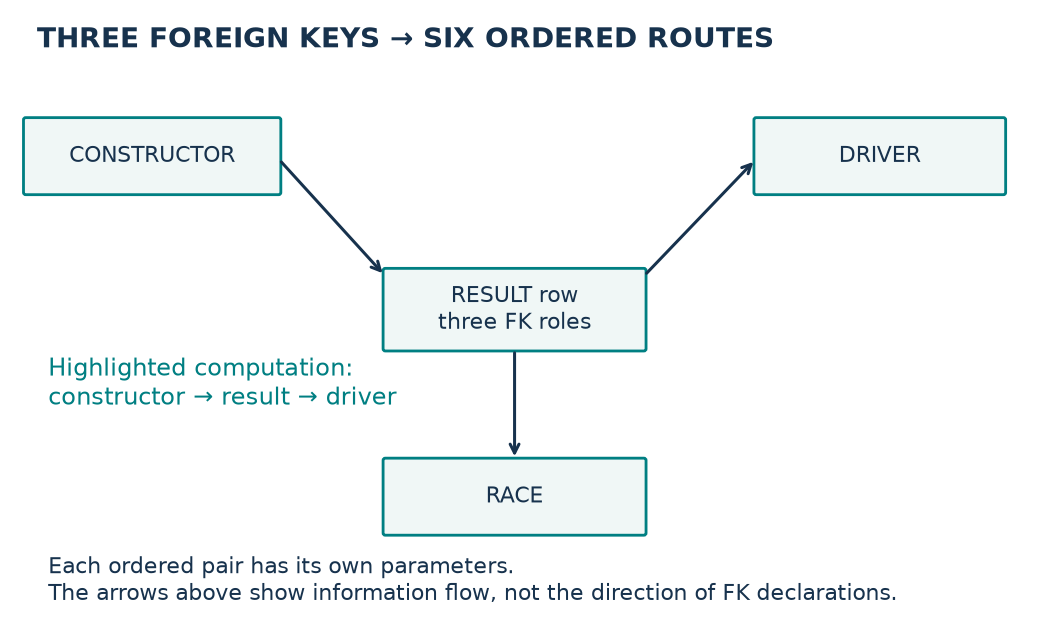<figcaption>A three-key result row yields six ordered composite routes. The pictured arrows show information flow; foreign key declarations point from result to each endpoint. Scroll horizontally on a narrow screen.</figcaption></figure>

**TODO 1 — `get_atomic_routes`.** Produce the released route tuples. A composite tuple stores the fact→destination attention edge first, then the source→fact fusion edge. That storage order is not the direction of the whole information path. The CHECK tests direction, role identity, reverse-edge handling and ordinary one-key routes. Your function constructs the routes used by the real model below.

> **Scope check.** The release includes special handling for self-referencing tables. Keep it in the implementation and source audit; the F1 worked example does not require a self-reference. Schema-derived routing does not itself establish useful predictive signal.



In [4]:
# TODO — this function is live in the implementation.
def get_atomic_routes(edge_type_list):
    
    src_to_tuples = defaultdict(list)
    for src, rel, dst in edge_type_list:
        if rel.startswith('f2p'):
            if src == dst:
                src = src + '--' + rel
            src_to_tuples[src].append((src, rel, dst))

    atomic_routes_list = []
    get_rev_edge = lambda edge: (edge[2], 'rev_' + edge[1], edge[0])
    for src, tuples in src_to_tuples.items():
        if '--' in src:
            src = src.split('--')[0]
        if len(tuples) == 1:
            _, rel, dst = tuples[0]
            edge = (src, rel, dst)
            atomic_routes_list.append(('dim-dim',) + edge)
            atomic_routes_list.append(('dim-dim',) + get_rev_edge(edge))
        else:
            for _, rel_q, dst_q in tuples:
                for _, rel_v, dst_v in tuples:
                    if rel_q != rel_v:
                        edge_q = (src, rel_q, dst_q)
                        edge_v = (src, rel_v, dst_v)                   
                        atomic_routes_list.append(('dim-fact-dim',) + edge_q + get_rev_edge(edge_v))

    return atomic_routes_list

In [5]:
# CHECK — run unchanged.
def check_routes(fn):
    edges=[('race','f2p_circuit','circuit'),('result','f2p_driver','driver'),('result','f2p_constructor','constructor'),('result','f2p_race','race')]
    out=fn(edges)
    assert len(out)==8, 'One ordinary FK gives two directions; three FKs give six ordered composite routes'
    assert ('dim-dim','race','f2p_circuit','circuit') in out
    assert ('dim-dim','circuit','rev_f2p_circuit','race') in out
    assert ('dim-fact-dim','result','f2p_driver','driver','constructor','rev_f2p_constructor','result') in out
    assert len(set(out))==8
    assert fn(edges+[(d,'rev_'+r,s) for s,r,d in edges])==out,'Reverse edges must not become foreign keys'
    assert len(fn([('result','f2p_home','team'),('result','f2p_away','team')]))==2,'Foreign key roles, not distinct target tables, identify routes'
    assert fn([])==[]
check_routes(get_atomic_routes)
print("PASS get_atomic_routes")

PASS get_atomic_routes


## 3 · Fuse one source role with the fact row

**A representation** is a vector of learned numerical features. Let `s` be the source vector, `f` the fact-row vector and `d` the destination vector. The fact still contributes its own attributes; the route does not turn it into an empty edge.

For the selected released variant, the intermediate representation is:

`u = W_source · sum(source neighbors) + b_source + W_fact · f`.

Here `W` denotes a learned linear map; `b` is a learned offset. The source sum collects only the source role belonging to this ordered route. A valid nonmissing foreign key has one parent, so that sum usually contains one source vector. A missing sampled edge gives a zero source sum; the fact-root term remains. These operations reproduce the released GraphSAGE fusion, including its bias and root contribution. [Composite operator source](https://avistian.github.io/relational/labs/sources/l141/examples__relgnn_conv.py)

**Worked example — deliberately scalar.** Two historical result rows point to the same driver. Their constructor coordinates are 2 and 4; their result coordinates are 1 and 0. Set both linear weights to 1 and the bias to 0. The fused messages are then **3 and 4**. This arithmetic is an illustration, not a measured F1 embedding.

The race role has its own route. It is not mixed into the constructor→result→driver intermediate above. The final driver representation may still include race information through other routes. “Pair-specific” does not mean “the entire network ignores every other table.”

An ordinary two-layer heterogeneous GNN may mix the source, destination and other roles into the intermediate before returning information to the destination. RelGNN changes where that mixing occurs. We will study failure examples more deeply in Lesson 142; a diagram alone cannot establish that one model must win.



## 4 · Let the destination weight its incoming messages

**Attention** assigns learned weights to incoming vectors. The destination supplies a *query* vector. Each fused intermediate supplies a *key* and a *value*. Queries and keys determine weights; values supply the content that is averaged.

For head `h` and an incoming fact `j`, the selected implementation computes:

```
q_h = W_query,h d + b_query,h
k_jh = W_key,h u_j + b_key,h
v_jh = W_value,h u_j + b_value,h
score_jh = dot(q_h, k_jh) / sqrt(128)
alpha_jh = exp(score_jh) / sum_incoming exp(score_h)
message_h = sum_incoming alpha_jh * v_jh
```

A **head** is a separate learned query/key/value projection. The denominator ranges over incoming edges to this destination, within this route and head. It does not range across the whole batch, across heads or across routes. Subtracting the largest score before exponentiation preserves the ratio and prevents overflow.

**Continue the scalar example.** Use identity key/value maps and a one-dimensional query of 1. The scores are 3 and 4; the scale is `sqrt(1)` in this illustration. Softmax gives approximately **0.269 and 0.731**, producing **3.731**. With query 0, both scores are equal: the result becomes **3.500**. The source messages are unchanged; only the destination's weighting changes.

**Predict:** will raising the query emphasize the larger fused value? Will adding an unrelated race coordinate alter this particular route's calculation?

Scalar baseline q=1: scores[3,4], weights[0.269,0.731], output3.731. Change q to0: output3.500.

<figure class="route-figure" tabindex="0">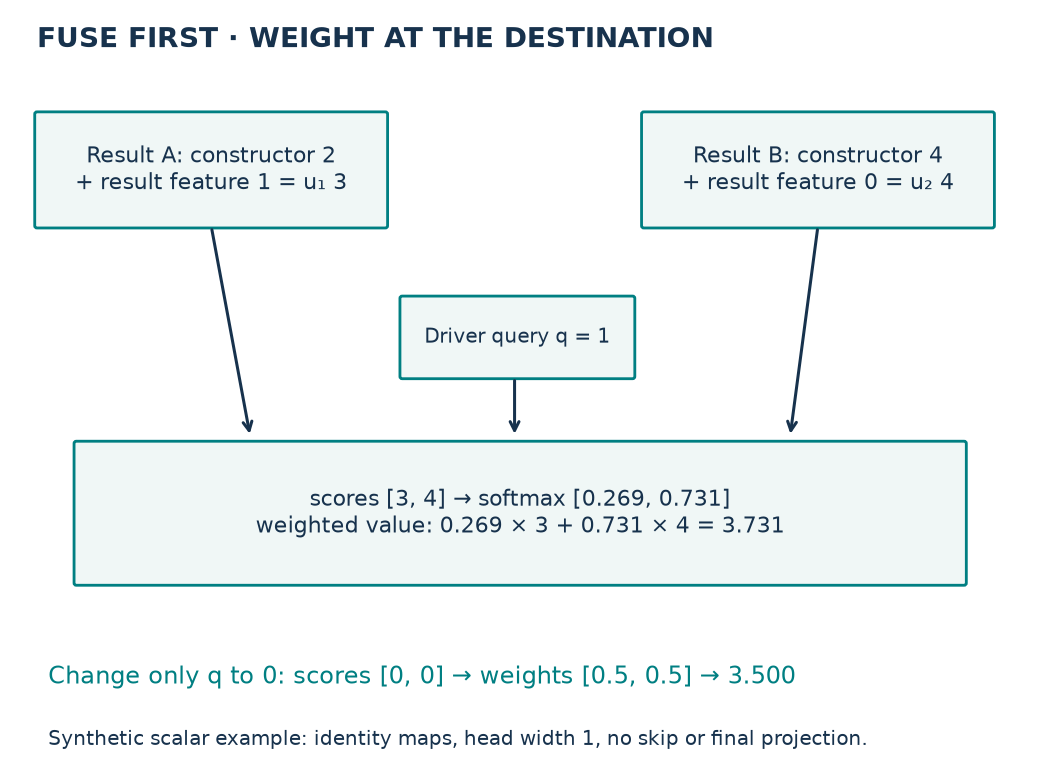<figcaption>Synthetic scalar calculation: constructor [2,4] plus result [1,0] gives fused [3,4]. Query 1 yields 3.731; query 0 yields 3.500. These are not measured embeddings. Scroll horizontally on a narrow screen.</figcaption></figure>

**TODO 2 — `destination_softmax`.** Normalize scores separately by destination and head. The CHECK uses two destinations, extreme scores, an unused destination, permuted edges and an empty edge set. The full attention forward pass calls your function, so a globally normalized answer changes the trained model.

The real operator concatenates four 128-channel head outputs to 512 channels, adds a learned destination skip vector of that width, and projects back to 128 channels. The skip supplies a direct route for the destination's current state. This release does **not** divide a total width of 128 into four 32-channel heads. [Visible arithmetic](https://avistian.github.io/relational/labs/relkit/relgnn_l141.py) · [Released operator](https://avistian.github.io/relational/labs/sources/l141/examples__relgnn_conv.py)



In [6]:
# TODO — this function is live in the implementation.
def destination_softmax(scores, destination, num_destinations):
    """Normalize each head over incoming messages for the same destination."""
    index = destination[:, None].expand_as(scores)
    maxima = scores.new_full((num_destinations, scores.shape[1]), -torch.inf)
    maxima.scatter_reduce_(0, index, scores.detach(), reduce='amax', include_self=True)
    weights = (scores - maxima[destination]).exp()
    totals = scores.new_zeros((num_destinations, scores.shape[1]))
    totals.index_add_(0, destination, weights)
    return weights / (totals[destination] + 1e-16)

In [7]:
# CHECK — run unchanged.
def check_softmax(fn):
    s=torch.tensor([[0.,1.],[math.log(3),1.],[1000.,-1000.]],dtype=torch.float64,requires_grad=True)
    dest=torch.tensor([0,0,2]);a=fn(s,dest,4)
    expected=torch.tensor([[.25,.5],[.75,.5],[1.,1.]],dtype=s.dtype)
    torch.testing.assert_close(a,expected,atol=1e-12,rtol=1e-12)
    p=torch.tensor([2,0,1]);torch.testing.assert_close(fn(s[p],dest[p],4),expected[p])
    assert fn(s[:0],dest[:0],4).shape==(0,2)
    (a*torch.arange(6).reshape(3,2)).sum().backward();assert torch.isfinite(s.grad).all()
check_softmax(destination_softmax)
print("PASS destination_softmax")

PASS destination_softmax


## 5 · Model architecture: one composite layer, two sampling hops

<figure class="route-figure" tabindex="0">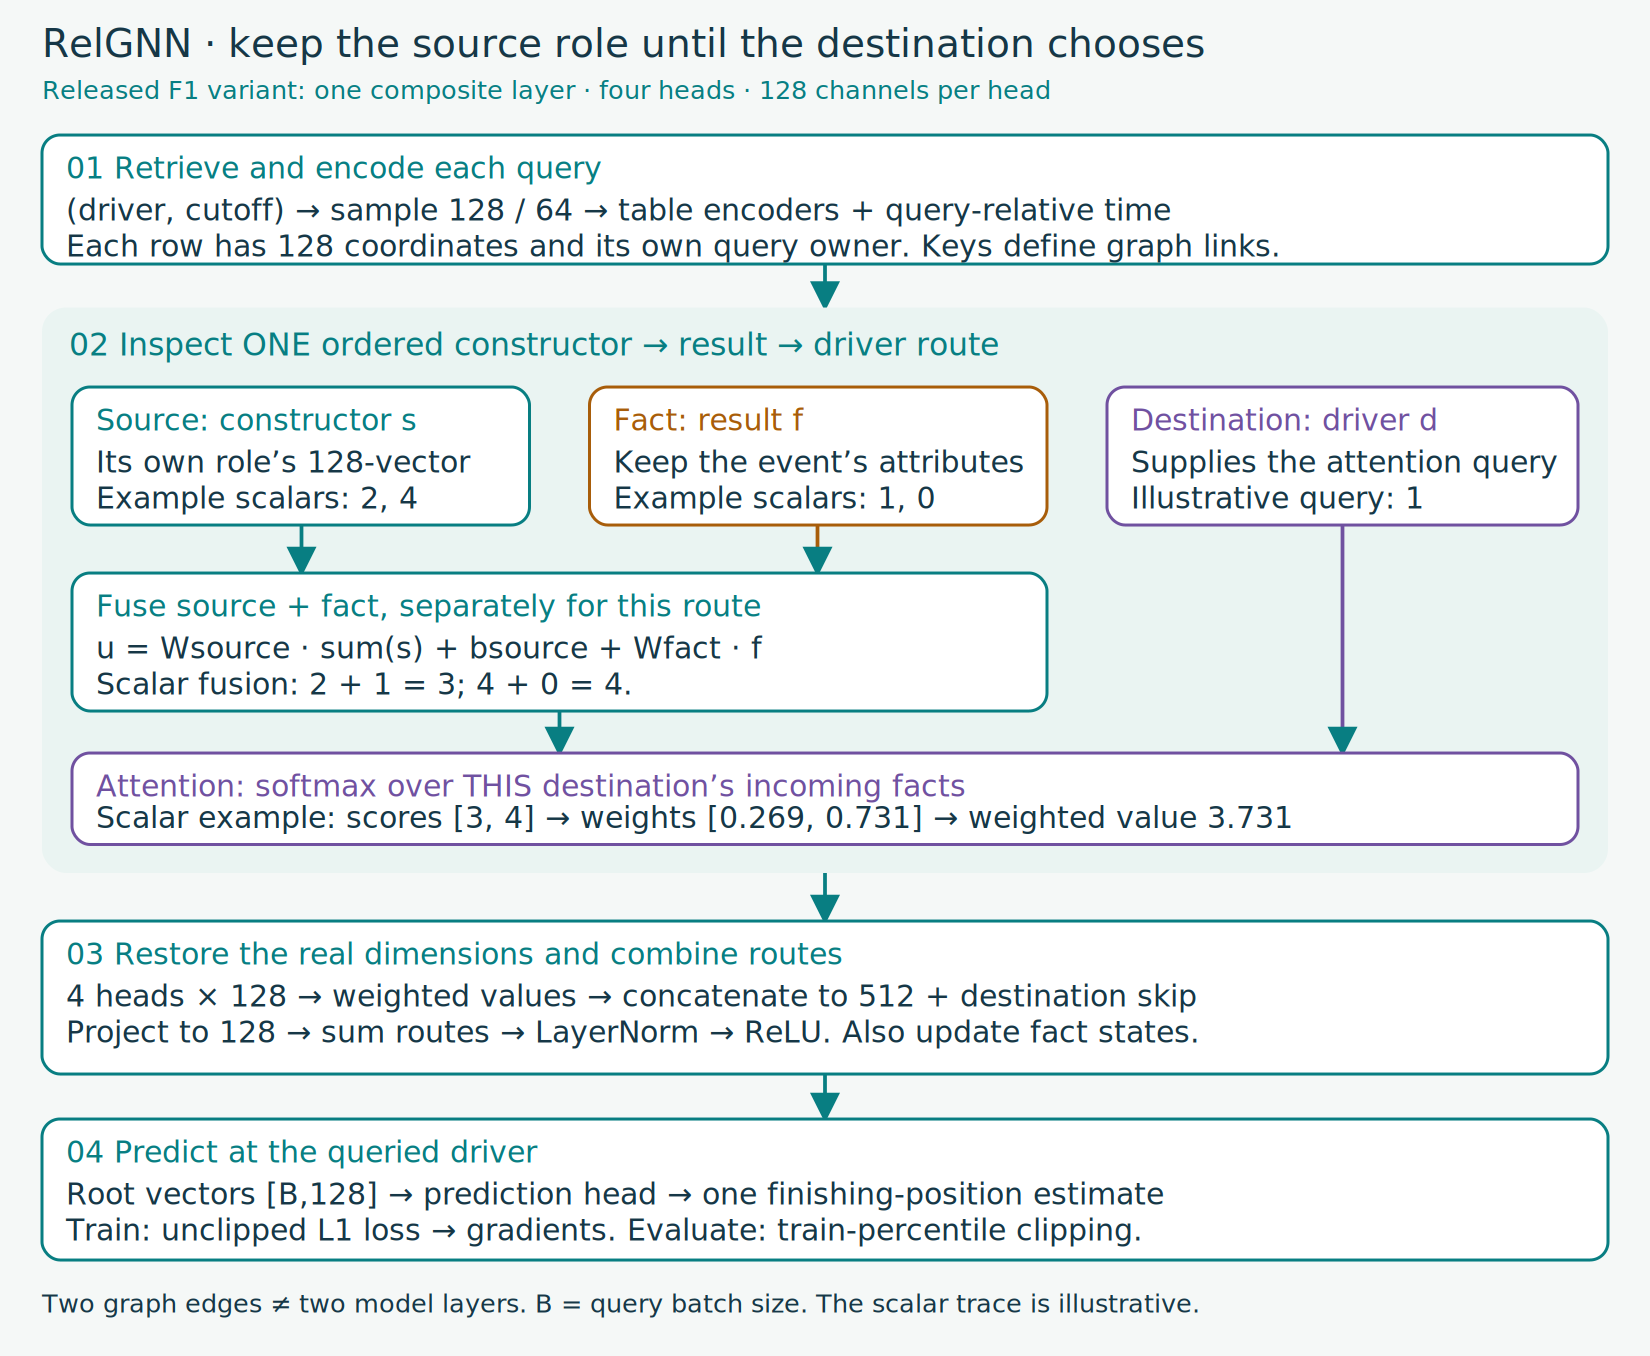<figcaption>Selected F1 model: two sampling hops, one composite layer, four 128-channel heads, route sums and a scalar driver head. The source/fact/driver route is highlighted inside the complete forward pass. Scroll horizontally on a narrow screen.</figcaption></figure>

**Input.** Each query is `(driver_id, cutoff)`. A temporal sampler gathers a neighborhood using fanouts 128 and 64: the maximum requested neighbors per edge type at each of two sampling hops. The selected release uses uniform sampling and a bidirectional sampled subgraph. Each sampled node occurrence retains the query that owns it.

**Encode.** Each table has its own row encoder. Categorical, numerical, timestamp and text features are mapped into a 128-channel row vector using the released PyTorch Frame stack. Text uses fixed GloVe word embeddings. A learned projection of a positional encoding adds the time difference between the query cutoff and the row timestamp, measured in days. Untimestamped tables do not receive that temporal term. [Encoder source](https://avistian.github.io/relational/labs/sources/l141/relbench__modeling__nn.py)

**Route.** Each atomic route uses its own parameter set. Composite routes first fuse a source role with a fact, then attend from fact to destination. Direct routes skip fusion. The release also sends each composite route's fused intermediate to the fact table's output accumulator; omitting that update changes the model.

**Update.** Sum outputs targeting the same table. Normalize each node vector across its channels, then apply ReLU, which replaces negative coordinates by zero. This is one **model layer**, although a composite message used two sampled graph edges. Model depth and sampler depth are different settings. [Stack](https://avistian.github.io/relational/labs/sources/l141/examples__relgnn_nn.py) · [Route dispatch](https://avistian.github.io/relational/labs/sources/l141/examples__relgnn_hetero_conv.py)

**Predict and train.** Select the driver roots and apply the released one-layer prediction head to obtain one scalar per query. L1 loss is the mean absolute error between predictions and training targets. Gradients update the row encoders, temporal projections, composite operators and head. At evaluation, clip predictions to the training targets' 2nd–98th percentile range. Training loss uses unclipped predictions.

> **Scope check.** Passing a timestamp test proves legality under the released event clocks. It does not supply missing historical arrival times or prove prospective feature availability. Atomic routes never authorize skipping either edge's owning-query cutoff.

**Trace check:** explain why the picture contains two graph edges but one composite layer. Identify where the fact's features enter, where the destination affects attention, and where different routes finally meet.



In [8]:
# PROVIDED — inspect this stage before running.
# %% Composite operator: role-specific fact representation then attention
class RelGNNConv(TransformerConv):
    def __init__(self, attn_type, in_channels, out_channels, heads, aggr,
                 simplified_MP=False, bias=True, **kwargs):
        super().__init__(in_channels, out_channels, heads, bias=bias, **kwargs)
        if aggr != 'sum' or simplified_MP:
            raise ValueError('This audited lesson implements the selected full sum variant')
        self.attn_type = attn_type
        if attn_type == 'dim-fact-dim':
            self.aggr_conv = SAGEConv(in_channels, out_channels, aggr=aggr)
        self.simplified_MP = simplified_MP
        self.final_proj = Linear(heads * out_channels, out_channels, bias=bias)
        self.final_proj.reset_parameters()

    def attend(self, source, destination, edges):
        # [nodes, heads, channels/head-output]; here each head outputs 128 channels.
        h, c = self.heads, self.out_channels
        q = self.lin_query(destination).view(-1, h, c)
        k = self.lin_key(source).view(-1, h, c)
        v = self.lin_value(source).view(-1, h, c)
        src, dst = edges
        scores = (q[dst] * k[src]).sum(-1) / math.sqrt(c)
        alpha = destination_softmax(scores, dst, len(destination))
        messages = v[src] * alpha[:, :, None]
        aggregate = messages.new_zeros((len(destination), h, c))
        aggregate.index_add_(0, dst, messages)
        # Source defaults: concatenate heads, add a destination skip, then project.
        joined = aggregate.reshape(len(destination), h*c) + self.lin_skip(destination)
        return self.final_proj(joined)

    def forward(self, x, edge_index, edge_attr=None, return_attention_weights=None):
        if edge_attr is not None or return_attention_weights is not None:
            raise ValueError('Selected experiment does not use edge attributes or attention return flags')
        if self.attn_type == 'dim-dim':
            return self.attend(x[0], x[1], edge_index)
        edge_attn, edge_aggr = edge_index
        source, fact, destination = x
        src, dst = edge_aggr
        gathered = source.new_zeros((len(fact), source.shape[1]))
        gathered.index_add_(0, dst, source[src])
        # SAGE sum + transformed fact root; unique to this ordered FK pair.
        intermediate = self.aggr_conv.lin_l(gathered) + self.aggr_conv.lin_r(fact)
        return self.attend(intermediate, destination, edge_attn), intermediate



In [9]:
# PROVIDED — inspect this stage before running.
# %% Route dispatch and route-output sums
def group(xs: List[Tensor], aggr: Optional[str]) -> Optional[Tensor]:
    if len(xs) == 0:
        return None
    elif aggr is None:
        return torch.stack(xs, dim=1)
    elif len(xs) == 1:
        return xs[0]
    elif aggr == "cat":
        return torch.cat(xs, dim=-1)
    else:
        out = torch.stack(xs, dim=0)
        out = getattr(torch, aggr)(out, dim=0)
        out = out[0] if isinstance(out, tuple) else out
        return out
class RelGNN_HeteroConv(torch.nn.Module):

    def __init__(self, convs, aggr: Optional[str]='sum', simplified_MP: Optional[bool]=False):
        super().__init__()
        self.convs = RouteModuleDict(convs)
        self.aggr = aggr
        self.simplified_MP = simplified_MP

    def reset_parameters(self):
        for conv in self.convs.values():
            conv.reset_parameters()

    def forward(self, x_dict, edge_index_dict) -> Dict[NodeType, Tensor]:
        out_dict: Dict[str, List[Tensor]] = {}

        def update(out_dict, dst, out):
            if dst not in out_dict:
                out_dict[dst] = [out]
            else:
                out_dict[dst].append(out)
        for edge_type_info, conv in self.convs.items():
            attn_type = edge_type_info[0]
            if attn_type == 'dim-dim':
                src, rel, dst = edge_type_info[1:]
                x = (x_dict.get(src, None), x_dict.get(dst, None))
                edge_index = edge_index_dict[src, rel, dst]
                out = conv(x, edge_index)
                if self.simplified_MP and out is None:
                    continue
                update(out_dict, dst, out)
            elif attn_type == 'dim-fact-dim':
                edge_attn, edge_aggr = (edge_type_info[1:4], edge_type_info[4:])
                src_attn, _, dst = edge_attn
                src_aggr = edge_aggr[0]
                x = (x_dict[src_aggr], x_dict[src_attn], x_dict[dst])
                edge_index = (edge_index_dict[edge_attn], edge_index_dict[edge_aggr])
                out = conv(x, edge_index)
                if self.simplified_MP and out is None:
                    continue
                out_dst, out_src_attn = out
                update(out_dict, dst, out_dst)
                update(out_dict, src_attn, out_src_attn)
        for key, value in out_dict.items():
            out_dict[key] = group(value, self.aggr)
        if self.simplified_MP:
            for key, value in x_dict.items():
                if key not in out_dict:
                    out_dict[key] = value
        return out_dict

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(num_relations={len(self.convs)})'


In [10]:
# PROVIDED — inspect this stage before running.
# %% Table encoders and query-relative time
class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict
class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


In [11]:
# PROVIDED — inspect this stage before running.
# %% Composite stack and node normalization
class RelGNN(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "sum",
        num_model_layers: int = 2,
        num_heads: int = 1,
        simplified_MP=False,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_model_layers):
            conv = RelGNN_HeteroConv(
                {
                    edge_type: RelGNNConv(edge_type[0], (channels, channels), channels, num_heads, aggr=aggr, simplified_MP=simplified_MP)
                    for edge_type in edge_types
                },
                aggr=aggr,
                simplified_MP=simplified_MP,
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_model_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict


In [12]:
# PROVIDED — inspect this stage before running.
# %% Whole-model forward pass: table -> time -> routes -> head
class RelGNN_Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_model_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
        atomic_routes=None,
        num_heads=None,
        simplified_MP=False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = RelGNN(
            node_types=data.node_types,
            edge_types=atomic_routes,
            channels=channels,
            aggr=aggr,
            num_model_layers=num_model_layers,
            num_heads=num_heads,
            simplified_MP=simplified_MP,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[dst_table])


In [13]:
# PROVIDED/CHECK: full model fixture and original operator differential test
"""Synthetic whole-model forward/backward; no paper-result claim."""
import pandas as pd
import torch
from torch_frame import stype
from torch_frame.data import Dataset
from torch_geometric.data import HeteroData

def neural_fixture(Model,route_builder):
    torch.set_num_threads(1);torch.manual_seed(141);data=HeteroData();stats={}
    for name,values in [('drivers',[1.,2.,3.,4.]),('results',[3.,5.,9.,10.]),('constructors',[2.,7.,11.,16.])]:
        frame=Dataset(pd.DataFrame({'x':values}),col_to_stype={'x':stype.numerical}).materialize()
        data[name].tf=frame.tensor_frame;stats[name]=frame.col_stats;data[name].num_nodes=4
        data[name].batch=torch.tensor([0,1,0,1]);data[name].n_id=torch.arange(4)
    data['drivers'].seed_time=torch.tensor([864000,1728000]);data['results'].time=torch.tensor([777600,1555200,691200,1468800])
    for dst,fk in [('drivers','driverId'),('constructors','constructorId')]:
        edge=torch.tensor([[0,1,2,3],[0,1,0,1]])
        data['results','f2p_'+fk,dst].edge_index=edge;data[dst,'rev_f2p_'+fk,'results'].edge_index=edge.flip(0)
    model=Model(data,stats,1,128,1,'sum','batch_norm',atomic_routes=route_builder(data.edge_types),num_heads=4)
    model.train();pred=model(data,'drivers').view(-1);assert pred.shape==(2,)
    loss=torch.nn.functional.l1_loss(pred,torch.tensor([3.,5.]));loss.backward();report={}
    for name,part in [('encoder',model.encoder),('time',model.temporal_encoder),('gnn',model.gnn),('head',model.head)]:
        grads=[p.grad for p in part.parameters() if p.grad is not None]
        assert grads and all(torch.isfinite(g).all() for g in grads)
        norm=sum(float(g.square().sum()) for g in grads)**.5;assert norm>0
        report[name]=norm
    return dict(status='PASS',prediction=pred.detach().tolist(),loss=float(loss.detach()),gradient_norms=report,scope='finite synthetic fixture; real missing-value gradients audited separately')

"""Original source differential check, including outputs and all active gradients."""
import contextlib,sys,types
from pathlib import Path
import torch

@contextlib.contextmanager
def original_modules(source_root):
    names=['atomic_routes','relgnn_conv','relgnn_hetero_conv','relgnn_nn','relgnn_model']
    old={n:sys.modules.get(n) for n in names}
    try:
        for name in names:
            m=types.ModuleType(name);sys.modules[name]=m
            exec(compile((Path(source_root)/('examples__'+name+'.py')).read_text(),name,'exec'),m.__dict__)
        yield sys.modules['relgnn_model'].RelGNN_Model,sys.modules['relgnn_conv'].RelGNNConv
    finally:
        for n,m in old.items():
            if m is None:sys.modules.pop(n,None)
            else:sys.modules[n]=m

def check(source_root):
    torch.manual_seed(141);torch.set_num_threads(1)
    errors=[];gradients=0
    with original_modules(source_root) as (_,Original):
        for mode in ['dim-dim','dim-fact-dim']:
            for empty in [False,True]:
                a=RelGNNConv(mode,(4,4),4,2,aggr='sum').double()
                b=Original(mode,(4,4),4,2,aggr='sum').double();b.load_state_dict(a.state_dict())
                x=[torch.randn(n,4,dtype=torch.float64,requires_grad=True) for n in ([3,2] if mode=='dim-dim' else [3,4,2])]
                y=[v.detach().clone().requires_grad_() for v in x]
                e=torch.tensor([[0,1,2],[0,0,1]]) if not empty else torch.empty((2,0),dtype=torch.long)
                edges=e if mode=='dim-dim' else (e,torch.tensor([[0,1,2],[0,1,2]]))
                oa=a(tuple(x),edges);ob=b(tuple(y),edges)
                aa=(oa,) if mode=='dim-dim' else oa;bb=(ob,) if mode=='dim-dim' else ob
                for u,v in zip(aa,bb):
                    torch.testing.assert_close(u,v,atol=1e-12,rtol=1e-12);errors.append(float((u-v).abs().max().detach()))
                sum(u.square().sum() for u in aa).backward();sum(u.square().sum() for u in bb).backward()
                for (ka,pa),(kb,pb) in zip(a.named_parameters(),b.named_parameters()):
                    assert ka==kb
                    if pa.grad is not None:
                        torch.testing.assert_close(pa.grad,pb.grad,atol=1e-11,rtol=1e-11);gradients+=1
                for u,v in zip(x,y):torch.testing.assert_close(u.grad,v.grad,atol=1e-11,rtol=1e-11)
    return dict(status='PASS',cases=4,parameter_gradient_tensors=gradients,max_output_error=max(errors),dtype='float64',scope='operator outputs/input and parameter gradients; empty attention edges included')

fixture_report=neural_fixture(RelGNN_Model,get_atomic_routes)
parity_report=check(SOURCE_ROOT)
print(fixture_report);print(parity_report)

{'status': 'PASS', 'prediction': [0.2750357985496521, 0.17854303121566772], 'loss': 3.7732105255126953, 'gradient_norms': {'encoder': 12.472479212084211, 'time': 2.9564404218610196, 'gnn': 15.724884797006611, 'head': 7.647992597504548}, 'scope': 'finite synthetic fixture; real missing-value gradients audited separately'}
{'status': 'PASS', 'cases': 4, 'parameter_gradient_tensors': 46, 'max_output_error': 0.0, 'dtype': 'float64', 'scope': 'operator outputs/input and parameter gradients; empty attention edges included'}


## 6 · Reproduce what the available evidence actually specifies

**Task meaning.** The target averages recorded finishing positions in `(cutoff, cutoff + 60 days]`. A driver needs an observed race result in that future window to receive a label; no future participation is not a zero finishing position. This is a benchmark population conditional on future participation, not a ready-made prospective roster of every driver. The independent audit rebuilds all 8,712 labels from raw result rows.

Our named target is **RelGNN, `rel-f1/driver-position`, Table 2: 3.798 test MAE**. Lower is better. The paper reports a five-seed mean. Its released entry point instead downloads one checkpoint and evaluates it. The complete historical training recipe and five individual training histories are not supplied. [Paper Table 2](https://arxiv.org/html/2502.06784v2#S5.T2) · [Released entry point](https://avistian.github.io/relational/labs/sources/l141/examples__relgnn_task_node.py)

We therefore keep three evidence columns: the paper's reported mean, a full-data replay of the released checkpoint, and five fresh runs under a frozen reconstruction. A close replay does not become five fresh fits; five fresh fits with documented choices do not become the historical training protocol.

| Decision | Released evidence | This reconstruction |
|---|---|---|
| Architecture | 1 composite layer, 128 channels, 4 heads, sum | Preserve |
| Sampling | Uniform 128/64, bidirectional, batch 512 | Preserve |
| Data / features | Complete F1 task; historical type cache absent | Checksum archives; freeze fresh inference; document replay override |
| Objective | L1 in paper / entry point | Preserve |
| Optimizer / schedule | Historical recipe unavailable | Adam 0.005, 10 full epochs |
| Runs | Paper averages 5 seeds | Fresh seeds 0–4 |
| Checkpoint selection | Historical history unavailable | First strict minimum validation MAE |
| Prediction clipping | Training-target percentiles 2 and 98 | Preserve |

**Checkpoint preprocessing gap.** Fresh type inference treats `qualifying.position` as categorical. The released checkpoint instead requires two numerical qualifying features. Its saved means and standard deviations match `number` and `position`, in that order. The initial unmodified replay fails strict weight loading. We retain that failure, rematerialize only this table with numerical position, and label the new lane **CHECKPOINT_COMPATIBILITY_REPLAY**. This is an evidence-backed reconstruction of one missing type choice; the historical type cache is still unavailable. Fresh training keeps the originally frozen inferred types. The two lanes therefore do not have identical feature semantics.

**Gradient-health gap.** The real numerical encoder can have nonfinite parameter gradients while yielding finite predictions. A clean synthetic fixture does not establish healthy optimization on missing real values. On a real training batch, 640 nonfinite numerical-weight gradients had identical masks in the original implementation; finite gradients agreed within 2.4×10⁻⁷ after matching dropout RNG. We preserve that behavior in these runs; a sanitized encoder would be a new experiment.

The fresh runs are **RECONSTRUCTED_TRAINING**. No seed is dropped because it is inconvenient. Test scores never select the epoch, learning rate or a retry. All training rows are visited in every epoch. The initial full seed is also the timing pilot. A predeclared ±0.20 MAE band is only a descriptive comparison with the paper scalar; it is not an equivalence test. Exact historical reproduction remains **NOT_ESTABLISHED** regardless of the score.

**TODO 3 — `keyed_mae`.** Align finite predictions by the complete unique `(driver, cutoff)` key, then compute absolute errors. Reject missing or duplicate keys. The default notebook deliberately shuffles every real prediction vector before scoring it with your function.

**Predict before inspecting results:** if the checkpoint is close but fresh reconstructed fits vary, what has each lane established? What evidence would be needed to claim a causal improvement over the old baseline?

| Evidence lane | Validation MAE | Test MAE | What was executed |
|---|---:|---:|---|
| Published Table 2 | — | 3.798 | Reported five-seed mean |
| Checkpoint-compatible replay | 2.836661 | 3.737381 | One released set of weights; reconstructed qualifying types |
| Fresh reconstruction, five seeds | 3.216126 ± 0.095152 | 4.259311 ± 0.267820 | Ten full epochs per seed; sample SD |

All **7,554 held-out predictions** independently aligned and rescored. Fresh score comparison: **OUTSIDE_TOLERANCE**. Historical training: **NOT_ESTABLISHED**. Whole paper: **NOT_RUN**.


<figure class="route-figure" tabindex="0">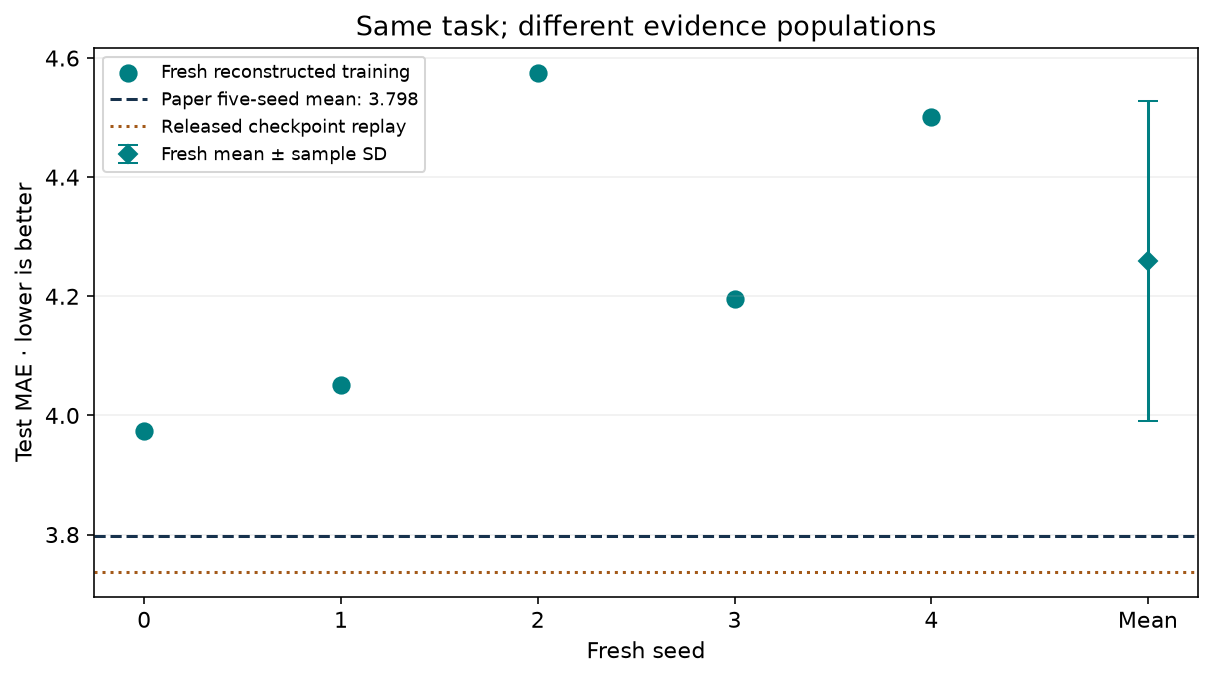<figcaption>Measured fresh seed points and mean ± sample SD; paper mean and checkpoint-compatible replay are separate evidence populations. No causal model comparison is established. Scroll horizontally on a narrow screen.</figcaption></figure>

These results are conditional on one task and fixed splits. Earlier lessons have already used this public test set; it is not a new pristine holdout. A fresh controlled baseline comparison would be required to attribute a gain to routing alone. A full 30-task paper reproduction is outside this selected experiment. [Protocol, commands, cost and deviation ledger](https://avistian.github.io/relational/labs/l141-reproduction.md)



In [14]:
# TODO — this function is live in the implementation.
def keyed_mae(query_keys, targets, prediction_keys, predictions):
    """A repeated entity at another cutoff is a distinct forecast."""
    q = [tuple(k) for k in query_keys]; p = [tuple(k) for k in prediction_keys]
    y = np.asarray(targets, dtype=float); pred = np.asarray(predictions, dtype=float)
    if not q or len(set(q)) != len(q) or len(set(p)) != len(p) or set(q) != set(p):
        raise ValueError('Require equal unique query-key populations')
    if y.shape != (len(q),) or pred.shape != (len(p),) or not np.isfinite(y).all() or not np.isfinite(pred).all():
        raise ValueError('Require finite one-dimensional targets and predictions')
    lookup = dict(zip(p, pred))
    return float(np.mean(np.abs(y - np.array([lookup[k] for k in q]))))

In [15]:
# CHECK — run unchanged.
def check_mae(fn):
    q=[(1,10),(1,20),(2,10)]
    assert fn(q,[1.,4.,2.],q[::-1],[3.,2.,1.])==1.
    for keys,pred in [(q[:2],[1.,2.]),([q[0],q[0],q[2]],[1.,2.,3.]),(q,[1.,float('nan'),3.])]:
        try:fn(q,[1.,4.,2.],keys,pred)
        except ValueError:pass
        else:raise AssertionError('Missing/duplicate/nonfinite prediction must fail')
check_mae(keyed_mae)
print("PASS keyed_mae")

PASS keyed_mae


In [16]:
# CHECK: your function evaluates all real author prediction vectors.
rows=[];rng=np.random.default_rng(141)
for phase in ['replay-compatible']+[f'seed-{i}' for i in range(5)]:
    for split in ['val','test']:
        prefix=phase+'_'+split+'_';keys=list(zip(DATA[prefix+'entity'],DATA[prefix+'time']))
        order=rng.permutation(len(keys))
        score=keyed_mae(keys,DATA[prefix+'target'],[keys[i] for i in order],DATA[prefix+'pred'][order])
        expected=float(np.mean(np.abs(DATA[prefix+'target']-DATA[prefix+'pred'])))
        assert abs(score-expected)<1e-12
        rows.append(dict(lane=phase,split=split,mae=score,queries=len(keys)))
display(pd.DataFrame(rows))
for phase,history in AUTHOR_HISTORIES.items():
    if history:assert len(history)==10 and all(x['queries']==7453 for x in history)
assert sum(r['queries'] for r in rows)==AUTHOR_SUMMARY['verified_predictions']


,lane,split,mae,queries
0,replay-compatible,val,2.836661,499
1,replay-compatible,test,3.737381,760
2,seed-0,val,3.225266,499
3,seed-0,test,3.974145,760
4,seed-1,val,3.233850,499
5,seed-1,test,4.051316,760
6,seed-2,val,3.258619,499
7,seed-2,test,4.575733,760
8,seed-3,val,3.307159,499
9,seed-3,test,4.195059,760


## 7 · Implement, explain, return later

Open the [student notebook](https://avistian.github.io/relational/labs/0141-composite-message-passing.ipynb). It contains the model and trainer in annotated code sections, with portable figures. Implement the three TODOs and run each CHECK. The default CPU lane uses synthetic operator examples and independently re-scores author evidence. The explicit full-data gate runs preprocessing, checkpoint replay and fresh training in the pinned GPU environment.

**EXIT — write before consulting the reference.** Draw one constructor→result→driver update. Include the fact-root term, destination query, normalization set, four-head dimensions and output projection. Explain why one model layer needs two sampling hops. Then write two separate sentences describing the checkpoint evidence and reconstructed training evidence. Name what neither establishes.

Write your EXIT explanation before consulting the reference answer.

Return tomorrow and reconstruct the route-count rule and attention denominator from memory. Next week, revisit the keyed-metric exercise with shuffled predictions. Lesson 142 examines many-to-many failure mechanisms; Lesson 143 extends the RelGNN reproduction work. This lesson's author execution does not complete those units or establish your mastery.

[One-page reference](https://avistian.github.io/relational/reference/composite-message-passing.html) · [Executed teacher notebook](https://avistian.github.io/relational/labs/html/0141-composite-message-passing.html). Ask the agent follow-up questions, or paste your EXIT explanation for feedback. Learner status remains **PENDING_WRITTEN_DEFENSE** until that explanation is assessed.


<!-- sequence-next:start -->
**Carry this forward.** Keep the scalar source–fact–destination example. Lesson 142 uses controlled input changes to show exactly what an ordinary update can mix or repeat. [Continue to Lesson 142](https://avistian.github.io/relational/lessons/0142-many-to-many-edge-pathology.html).
<!-- sequence-next:end -->


## Post-EXIT: full-data reproduction code

The complete preprocessing and trainer are visible below. They preserve live learner functions. The original source is only the differential oracle. Fresh training uses the frozen course recipe, and the compatibility helper documents the released checkpoint type mismatch. The GPU gate is off by default. See the protocol for budget and pinned execution commands.

In [17]:
# PROVIDED: released graph construction and query loader inputs
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )


class LinkTrainTableInput(NamedTuple):
    r"""Training table input for link prediction.

    - src_nodes is a Tensor of source node indices.
    - dst_nodes is PyTorch sparse tensor in csr format.
        dst_nodes[src_node_idx] gives a tensor of destination node
        indices for src_node_idx.
    - num_dst_nodes is the total number of destination nodes.
        (used to perform negative sampling).
    - src_time is a Tensor of time for src_nodes
    """

    src_nodes: Tuple[NodeType, Tensor]
    dst_nodes: Tuple[NodeType, Tensor]
    num_dst_nodes: int
    src_time: Optional[Tensor]


def get_link_train_table_input(
    table: Table,
    task: RecommendationTask,
) -> LinkTrainTableInput:
    r"""Get the training table input for link prediction."""

    src_node_idx: Tensor = torch.from_numpy(
        table.df[task.src_entity_col].astype(int).values
    )
    exploded = table.df[task.dst_entity_col].explode()
    coo_indices = torch.from_numpy(
        np.stack([exploded.index.values, exploded.values.astype(int)])
    )
    sparse_coo = torch.sparse_coo_tensor(
        coo_indices,
        torch.ones(coo_indices.size(1), dtype=bool),
        (len(src_node_idx), task.num_dst_nodes),
    )
    dst_node_indices = sparse_coo.to_sparse_csr()

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    return LinkTrainTableInput(
        src_nodes=(task.src_entity_table, src_node_idx),
        dst_nodes=(task.dst_entity_table, dst_node_indices),
        num_dst_nodes=task.num_dst_nodes,
        src_time=time,
    )


In [18]:
# PROVIDED: frozen full-data trainer
"""Full released-checkpoint replay and explicitly reconstructed fresh training.

Reconstruction: five seeds, ten complete epochs, Adam .005, L1, first validation
minimum. These choices are frozen course choices; historical training is unreleased.
"""
import hashlib,json,time,copy
from pathlib import Path
import numpy as np
import torch
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from torch_frame.config import TextEmbedderConfig
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.modeling.utils import get_stype_proposal

ARCHIVES={'db.zip':'ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482','tasks/driver-position.zip':'775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e'}
CHECKPOINT_REVISION='321e6f6e7af5d7546b637f147783fc28ab5d4a7a'
CONFIG=dict(num_model_layers=1,channels=128,aggr='sum',num_heads=4)



In [19]:
# PROVIDED: frozen full-data trainer
def sha(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        while chunk:=f.read(8*1024*1024):h.update(chunk)
    return h.hexdigest()



In [20]:
# PROVIDED: frozen full-data trainer
def materialize(root,source_root):
    """Fresh full test-cutoff database and released GloVe row materialization."""
    import urllib.request,zipfile,importlib.metadata as md
    from sentence_transformers import SentenceTransformer
    from huggingface_hub import hf_hub_download
    root=Path(root);root.mkdir(parents=True,exist_ok=False);seed_everything(42);torch.set_num_threads(1)
    for name,digest in ARCHIVES.items():
        target=root/'cache'/name;target.parent.mkdir(parents=True,exist_ok=True)
        urllib.request.urlretrieve('https://relbench.stanford.edu/download/rel-f1/'+name,target)
        assert sha(target)==digest
        with zipfile.ZipFile(target) as z:z.extractall(root/'unpacked')
    dataset=get_dataset('rel-f1');dataset.cache_dir=str(root/'unpacked');dataset.get_db.cache_clear();db=dataset.get_db()
    # Fail closed if installed preprocessing differs from the vendored release.
    import relbench.modeling.graph as graph,relbench.modeling.nn as nn,relbench.modeling.utils as utils
    source_checks={}
    for module,name in [(graph,'graph'),(nn,'nn'),(utils,'utils')]:
        expected=Path(source_root)/f'relbench__modeling__{name}.py'
        source_checks[name]=Path(module.__file__).read_bytes()==expected.read_bytes()
    assert all(source_checks.values()),source_checks
    types=get_stype_proposal(db)
    text=SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d',revision='e5e8fec6971be8960cfaa853a77a6ddc62a265d7',device='cpu')
    def embed(strings):return text.encode(strings,convert_to_tensor=True)
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=str(root/'materialized'))
    # Independent FK reconstruction from table rows, including missing references.
    fk_edges=0
    for table_name,table in db.table_dict.items():
        for column,parent in table.fkey_col_to_pkey_table.items():
            df=db.table_dict[parent].df;pk=db.table_dict[parent].pkey_col
            lookup={int(v):i for i,v in enumerate(df[pk])}
            expected={(i,lookup[int(v)]) for i,v in enumerate(table.df[column]) if not __import__('pandas').isna(v)}
            actual=set(map(tuple,data[(table_name,'f2p_'+column,parent)].edge_index.numpy().T))
            assert actual==expected,(table_name,column);fk_edges+=len(actual)
    torch.save((data,stats),root/'graph.pt')
    checkpoint=hf_hub_download('tianlangchen/RelGNN','rel-f1_driver-position.pth',revision=CHECKPOINT_REVISION)
    import shutil;shutil.copyfile(checkpoint,root/'released.pth')
    info=dict(graph_sha256=sha(root/'graph.pt'),checkpoint_sha256=sha(root/'released.pth'),checkpoint_revision=CHECKPOINT_REVISION,
        preprocessing='FRESH full released snapshot; seed42; pinned GloVe',archives=ARCHIVES,source_checks=source_checks,
        rows={k:len(t) for k,t in db.table_dict.items()},fk_edges=fk_edges,edges=sum(e.shape[1] for e in data.edge_index_dict.values()),
        routes=[list(r) for r in get_atomic_routes(data.edge_types)],packages={k:md.version(k) for k in ['torch','torch-geometric','pytorch-frame','relbench','numpy','pandas','sentence-transformers','pyg-lib']})
    (root/'prepared.json').write_text(json.dumps(info,indent=2));return info



In [21]:
# PROVIDED: frozen full-data trainer
def full_run(output,prepared_root,source_root,seed=0,replay=False):
    """All query rows are used. Test is opened only after validation selection."""
    start=time.perf_counter();torch.set_num_threads(1);seed_everything(42 if replay else seed)
    out=Path(output);out.mkdir(parents=True,exist_ok=False);root=Path(prepared_root)
    prepared=json.loads((root/'prepared.json').read_text());assert sha(root/'graph.pt')==prepared['graph_sha256']
    for name,digest in ARCHIVES.items():assert sha(root/'cache'/name)==digest
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    dataset=get_dataset('rel-f1');dataset.cache_dir=str(root/'unpacked');dataset.get_db.cache_clear()
    task=get_task('rel-f1','driver-position');task.cache_dir=str(root/'unpacked'/'driver-position');task.get_table.cache_clear()
    train=task.get_table('train');clip=np.percentile(train.df[task.target_col].to_numpy(),[2,98]).tolist()
    device='cuda' if torch.cuda.is_available() else 'cpu'
    kwargs=dict(data=data,col_stats_dict=stats,out_channels=1,norm='batch_norm',atomic_routes=get_atomic_routes(data.edge_types),**CONFIG)
    model=RelGNN_Model(**kwargs).to(device)
    # Initial lazy columns must be materialized before a new optimizer is created.
    def loader(split):
        table=task.get_table(split,mask_input_cols=False)
        input_table=table
        if split=='test':
            from relbench.base import Table
            input_table=Table(df=table.df.drop(columns=[task.target_col]),fkey_col_to_pkey_table=table.fkey_col_to_pkey_table,pkey_col=table.pkey_col,time_col=table.time_col)
        inp=get_node_train_table_input(table=input_table,task=task)
        return NeighborLoader(data,num_neighbors=[128,64],time_attr='time',input_nodes=inp.nodes,input_time=inp.time,transform=inp.transform,subgraph_type='bidirectional',batch_size=512,temporal_strategy='uniform',shuffle=split=='train',num_workers=0),table
    # Replay construction order matches source: val loader, test loader, model initialization.
    # Constructors do not sample; seed reset below matches original parameter RNG consumption.
    val_loader,val_table=loader('val')
    train_loader,_=loader('train') if not replay else (None,None)
    audit=dict(query_occurrences=0,timestamped_node_occurrences=0,future_violations=0);trace={};grad_norm=None
    def audit_batch(batch):
        cut=batch[task.entity_table].seed_time
        audit['query_occurrences']+=len(cut)
        for name,times in batch.time_dict.items():
            owners=batch[name].batch;bad=int((times>cut[owners]).sum());audit['future_violations']+=bad
            audit['timestamped_node_occurrences']+=len(times)
            assert bad==0,'Future node relative to owning query'
        if not trace:
            trace['cutoffs']=cut.cpu().numpy()
            for name,times in batch.time_dict.items():
                trace[name+'_times']=times.cpu().numpy();trace[name+'_owners']=batch[name].batch.cpu().numpy()
    def evaluate(dl,table,original=None):
        model.eval();parts=[];ids=[];max_error=0.
        with torch.no_grad():
            for batch in dl:
                audit_batch(batch);ids.append(batch[task.entity_table].input_id.cpu().numpy());batch=batch.to(device)
                p=model(batch,task.entity_table).view(-1)
                if original is not None:
                    q=original(batch,task.entity_table).view(-1)
                    error=float((p-q).abs().max());max_error=max(max_error,error)
                    torch.testing.assert_close(p,q,atol=2e-4,rtol=2e-4)
                parts.append(p.clamp(*clip).cpu().numpy())
        ids=np.concatenate(ids);pred=np.concatenate(parts);assert np.array_equal(np.sort(ids),np.arange(len(table)))
        frame=table.df;entity=frame[task.entity_col].to_numpy(dtype=np.int64)
        times=(frame[task.time_col].astype('int64')//10**9).to_numpy();target=frame[task.target_col].to_numpy()
        keys=list(zip(entity,times));predkeys=[keys[i] for i in ids]
        score=keyed_mae(keys,target,predkeys,pred)
        aligned=np.empty_like(pred);aligned[ids]=pred
        assert abs(score-task.evaluate(aligned,table)['mae'])<1e-10
        return dict(mae=score,entity=entity,time=times,target=target,pred=aligned,max_original_error=max_error)
    history=[];best=float('inf');best_epoch=None
    if replay:
        assert sha(root/'released.pth')==prepared['checkpoint_sha256']
        model.load_state_dict(torch.load(root/'released.pth',map_location=device,weights_only=False))
        # Model creation above matches release seed42; checkpoint fills every parameter.
    else:
        model.eval()
        with torch.no_grad():model(next(iter(train_loader)).to(device),task.entity_table)
        optimizer=torch.optim.Adam(model.parameters(),lr=.005)
        for epoch in range(1,11):
            model.train();total=0.;seen=0;steps=0
            for batch in train_loader:
                audit_batch(batch)
                assert np.array_equal(batch[task.entity_table].y.numpy(),train.df[task.target_col].to_numpy()[batch[task.entity_table].input_id.numpy()])
                batch=batch.to(device);optimizer.zero_grad()
                p=model(batch,task.entity_table).view(-1);y=batch[task.entity_table].y
                loss=torch.nn.functional.l1_loss(p,y);assert bool(torch.isfinite(loss));loss.backward()
                if grad_norm is None:grad_norm=float(sum(v.grad.square().sum() for v in model.parameters() if v.grad is not None).sqrt())
                optimizer.step();total+=float(loss.detach())*len(y);seen+=len(y);steps+=1
            assert seen==len(train)
            metric=evaluate(val_loader,val_table)['mae']
            history.append(dict(epoch=epoch,train_l1=total/seen,val_mae=metric,queries=seen,steps=steps))
            if metric<best:
                best=metric;best_epoch=epoch;torch.save(model.state_dict(),out/'selected.pt')
            (out/'progress.json').write_text(json.dumps(history,indent=2))
            print('seed',seed,'epoch',epoch,'val',metric,flush=True)
        model.load_state_dict(torch.load(out/'selected.pt',map_location=device,weights_only=False))
    # Compare all held-out raw outputs with original architecture at identical weights/batches.
    with original_modules(source_root) as (Original,_):
        # Constructing the parity oracle must not change neighborhood sampling RNG.
        with torch.random.fork_rng(devices=[torch.cuda.current_device()] if torch.cuda.is_available() else []):
            original=Original(**kwargs).to(device);original.load_state_dict(model.state_dict());original.eval()
        # Original replay samples test first and never consumes validation sampling RNG.
        test_loader,test_table=loader('test')
        scores={};arrays={}
        for split,dl,table in [('test',test_loader,test_table),('val',val_loader,val_table)]:
            ev=evaluate(dl,table,original);scores[split]={'mae':ev.pop('mae'),'max_original_error':ev.pop('max_original_error')}
            for k,v in ev.items():arrays[split+'_'+k]=v
    np.savez_compressed(out/'predictions.npz',**arrays);np.savez_compressed(out/'sampled_trace.npz',**trace)
    result=dict(status='COMPLETE',kind='RELEASED_CHECKPOINT_REPLAY' if replay else 'RECONSTRUCTED_TRAINING',seed=42 if replay else seed,
        epochs=0 if replay else 10,history=history,best_epoch=best_epoch,selection_mae=None if replay else best,scores=scores,
        count={'train':len(train),'val':len(val_table),'test':len(test_table)},clip=clip,config=CONFIG,gradient_norm=grad_norm,
        graph_sha256=prepared['graph_sha256'],checkpoint_sha256=prepared['checkpoint_sha256'] if replay else sha(out/'selected.pt'),
        temporal_audit=audit,seconds=time.perf_counter()-start,paper_target=3.798,historical_training='NOT_ESTABLISHED')
    (out/'result.json').write_text(json.dumps(result,indent=2));return result


In [22]:
# PROVIDED: explicit checkpoint compatibility reconstruction
"""One documented feature-type reconstruction for the released checkpoint.

Fresh inference classifies qualifying.position as categorical. Saved checkpoint
weights require two numerical columns. Their mean/std identify number,position.
This is compatibility evidence, not recovery of the historical stypes cache.
"""
import json
from pathlib import Path
import numpy as np
import torch
from torch_frame import stype
from torch_frame.data import Dataset
from relbench.datasets import get_dataset

def prepare_checkpoint_compatibility(prepared_root,output_root):
    root=Path(prepared_root).resolve();out=Path(output_root);out.mkdir(parents=True,exist_ok=False)
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    cp=torch.load(root/'released.pth',map_location='cpu',weights_only=False)
    dataset=get_dataset('rel-f1');dataset.cache_dir=str(root/'unpacked');dataset.get_db.cache_clear();df=dataset.get_db().table_dict['qualifying'].df
    columns={col:typ for typ,cols in data['qualifying'].tf.col_names_dict.items() for col in cols}
    assert columns['position']==stype.categorical and columns['number']==stype.numerical
    old={k:str(v) for k,v in columns.items()};columns['position']=stype.numerical
    frame=Dataset(df,col_to_stype=columns).materialize()
    assert frame.tensor_frame.col_names_dict[stype.numerical]==['number','position']
    prefix='encoder.encoders.qualifying.encoder.encoder_dict.numerical.'
    checks={}
    for kind,values in [('mean',df[['number','position']].mean().to_numpy()),('std',df[['number','position']].std(ddof=0).to_numpy())]:
        actual=cp[prefix+kind].numpy();np.testing.assert_allclose(values,actual,rtol=1e-6,atol=1e-6)
        checks[kind]={'table':values.tolist(),'checkpoint':actual.tolist()}
    data['qualifying'].tf=frame.tensor_frame;stats['qualifying']=frame.col_stats
    torch.save((data,stats),out/'graph.pt')
    for name in ['cache','unpacked','released.pth']:(out/name).symlink_to(root/name,target_is_directory=name!='released.pth')
    info=json.loads((root/'prepared.json').read_text());info['parent_graph_sha256']=info['graph_sha256'];info['graph_sha256']=sha(out/'graph.pt')
    info['preprocessing']='CHECKPOINT_COMPATIBILITY_RECONSTRUCTION; qualifying.position categorical->numerical'
    info['compatibility']={'before':old,'after':{k:str(v) for k,v in columns.items()},'evidence':checks,'historical_stypes_cache':'NOT_ESTABLISHED','unchanged_other_tables':True}
    (out/'prepared.json').write_text(json.dumps(info,indent=2));return info


In [23]:
# PROVIDED: expensive full-data execution is explicit and separate from the default lane.
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md
    for name,version in {'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}.items():
        assert md.version(name).split('+')[0]==version,(name,'requires pinned runtime')
    assert torch.cuda.is_available(),'Pinned GPU environment required'
    prepared=Path(PREPARED_ROOT) if PREPARED_ROOT else Path('l141-prepared')
    if PREPARED_ROOT is None:materialize(prepared,SOURCE_ROOT)
    replay_root=Path('l141-compatible')
    prepare_checkpoint_compatibility(prepared,replay_root)
    replay_result=full_run(Path('l141-runs/replay-compatible'),replay_root,SOURCE_ROOT,replay=True)
    fresh_results=[full_run(Path('l141-runs')/f'seed-{seed}',prepared,SOURCE_ROOT,seed) for seed in FULL_SEEDS]
    print('Full execution complete; historical training remains NOT_ESTABLISHED')
else:print('Default lane: full fresh training NOT_RUN; author evidence independently rescored.')


Default lane: full fresh training NOT_RUN; author evidence independently rescored.


In [24]:
report=dict(status='PASS',predictions=sum(r['queries'] for r in rows),fixture=fixture_report,operator=parity_report,full_training='RUN' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l141-report.json').write_text(json.dumps(report,indent=2))
print(report)

{'status': 'PASS', 'predictions': 7554, 'fixture': {'status': 'PASS', 'prediction': [0.2750357985496521, 0.17854303121566772], 'loss': 3.7732105255126953, 'gradient_norms': {'encoder': 12.472479212084211, 'time': 2.9564404218610196, 'gnn': 15.724884797006611, 'head': 7.647992597504548}, 'scope': 'finite synthetic fixture; real missing-value gradients audited separately'}, 'operator': {'status': 'PASS', 'cases': 4, 'parameter_gradient_tensors': 46, 'max_output_error': 0.0, 'dtype': 'float64', 'scope': 'operator outputs/input and parameter gradients; empty attention edges included'}, 'full_training': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE'}
